In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [55]:
# Caricamento Dataset
iris = load_iris()

# Creazioen Datafra,e
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Stampa descrittiva
print(df.describe())

# Separazione dalle features
x = df.values

       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000          1.300000
75%             6.400000          3.300000           5.100000          1.800000
max             7.900000          4.400000           6.900000          2.500000


In [56]:
# Creazione scaler
scaler = StandardScaler()

# Standardizzazione
x_std = scaler.fit_transform(x)

# Controllo 
print(x_std[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
# Lista eps da testare
eps_values = [0.35, 0.45, 0.55]

results = []

# Iteriamo su ciascun vaore di eps
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)

    labels = dbscan.fit_predict(x_std)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise_points = list(labels).count(-1)

    results.append({
        'eps' : eps,
        'K_clusters' : n_clusters,
        'Noise_points' : noise_points
    })

# Datafrane dai dati raccolti
result_df = pd.DataFrame(results)
print(result_df)

    eps  K_clusters  Noise_points
0  0.35           4           104
1  0.45           3            54
2  0.55           2            29


In [ ]:
# WCSS 
wcss = []

k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_std)
    wcss.append(kmeans.inertia_)

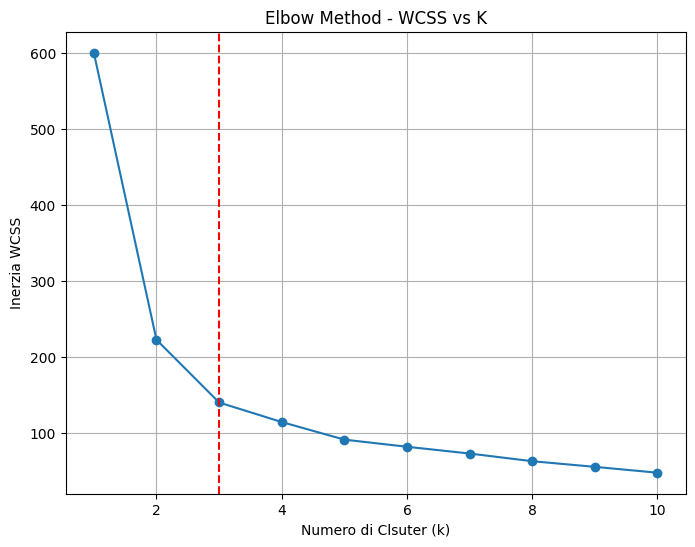

In [ ]:
# Creazione Plot
plt.figure(figsize=(8,6))
plt.plot(k_range, wcss, marker='o')

plt.axvline(x=3, color='red', linestyle='--', label='K scelto = 3')

plt.title('Elbow Method - WCSS vs K')
plt.xlabel('Numero di Clsuter (k)')
plt.ylabel('Inerzia WCSS')
plt.grid()
plt.show()

In [ ]:
# PCA e trasformazione di x_std
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_std)

In [ ]:
# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

labels = kmeans.fit_predict(x_std)

centroids = pca.transform(kmeans.cluster_centers_)

In [ ]:
# Silhouette score
score = silhouette_score(x_std, labels)
print(f'Silhouette score: {score}')

Silhouette score: 0.45994823920518646


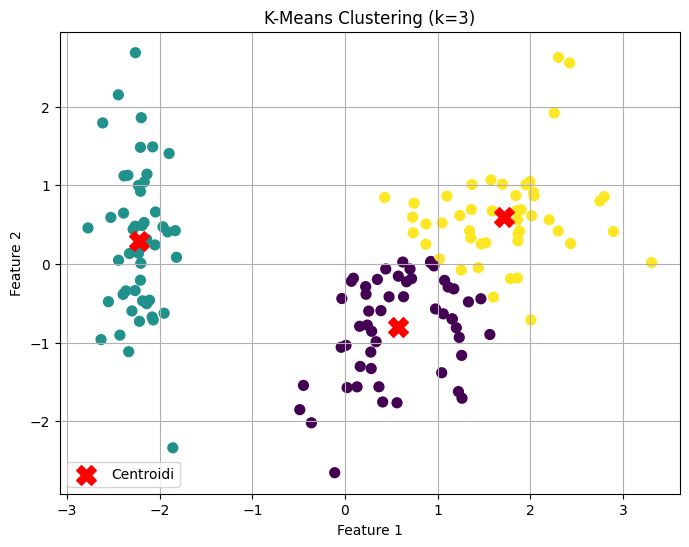

In [ ]:
# Creazione Scatter con centroidi
plt.figure(figsize=(8,6))

plt.scatter(x_pca[:,0], x_pca[:,1], c=labels, cmap='viridis', s=50)

plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200, label='Centroidi')

plt.title('K-Means Clustering (k=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()